# Logistic Regression: NumPy vs scikit-learn

This notebook is executable from the chapter directory.

## Learning goals

1. Visualize the sigmoid function.
2. Implement binary logistic regression with NumPy.
3. Verify cross-entropy decreases during training.
4. Compare probabilities and predictions with scikit-learn.
5. Inspect a two-dimensional decision boundary.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score
from sklearn.preprocessing import StandardScaler

REPO = Path.cwd().parents[1]
sys.path.insert(0, str(REPO / "src"))

from ml_foundations.logistic_regression import (
    LogisticRegressionGD,
    binary_cross_entropy,
    stable_sigmoid,
)

ASSETS = Path.cwd() / "assets"
ASSETS.mkdir(exist_ok=True)
rng = np.random.default_rng(42)

## Sigmoid

The linear score can be any real number. Sigmoid maps it to a probability-like value in `(0, 1)`.

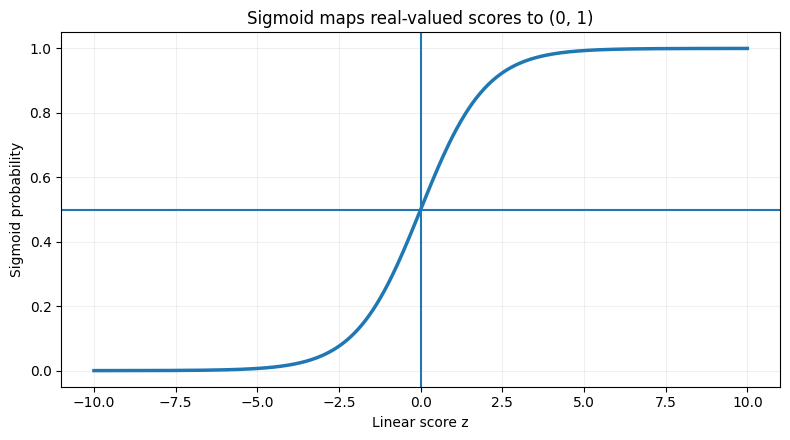

In [2]:
z = np.linspace(-10, 10, 500)
probability = stable_sigmoid(z)

plt.figure(figsize=(8, 4.5))
plt.plot(z, probability, linewidth=2.5)
plt.axhline(0.5, linewidth=1.5)
plt.axvline(0.0, linewidth=1.5)
plt.xlabel("Linear score z")
plt.ylabel("Sigmoid probability")
plt.title("Sigmoid maps real-valued scores to (0, 1)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(ASSETS / "sigmoid_curve.png", dpi=160)
plt.show()

## Create a two-feature binary dataset

We use two features so the decision boundary can be visualized. The training and test sets are separated before scaling.

In [3]:
n = 700
X0 = rng.normal(loc=[-1.2, -0.7], scale=[1.0, 1.2], size=(n // 2, 2))
X1 = rng.normal(loc=[1.3, 1.0], scale=[1.1, 0.9], size=(n // 2, 2))
X = np.vstack([X0, X1])
y = np.concatenate([np.zeros(n // 2, dtype=int), np.ones(n // 2, dtype=int)])

order = rng.permutation(n)
X, y = X[order], y[order]
split = 520
X_train_raw, X_test_raw = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

scaler = StandardScaler().fit(X_train_raw)
X_train = scaler.transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print("Train shape:", X_train.shape)
print("Positive rate:", y_train.mean())

Train shape: (520, 2)
Positive rate: 0.48653846153846153


## Train the NumPy model

The gradient is `X.T @ (p - y) / n`. The intercept is included internally and is not regularized.

In [4]:
numpy_model = LogisticRegressionGD(
    learning_rate=0.12,
    max_iter=5000,
    tol=1e-10,
    l2=0.0,
).fit(X_train, y_train)

p_numpy = numpy_model.predict_proba(X_test)[:, 1]
pred_numpy = (p_numpy >= 0.5).astype(int)

print("NumPy intercept:", round(numpy_model.intercept_, 5))
print("NumPy coefficients:", np.round(numpy_model.coef_, 5))
print("NumPy log-loss:", round(log_loss(y_test, p_numpy), 5))
print("NumPy ROC-AUC:", round(roc_auc_score(y_test, p_numpy), 5))
print("NumPy accuracy:", round(accuracy_score(y_test, pred_numpy), 5))

NumPy intercept: -0.15088
NumPy coefficients: [3.49728 1.76085]
NumPy log-loss: 0.19246
NumPy ROC-AUC: 0.97715
NumPy accuracy: 0.92222


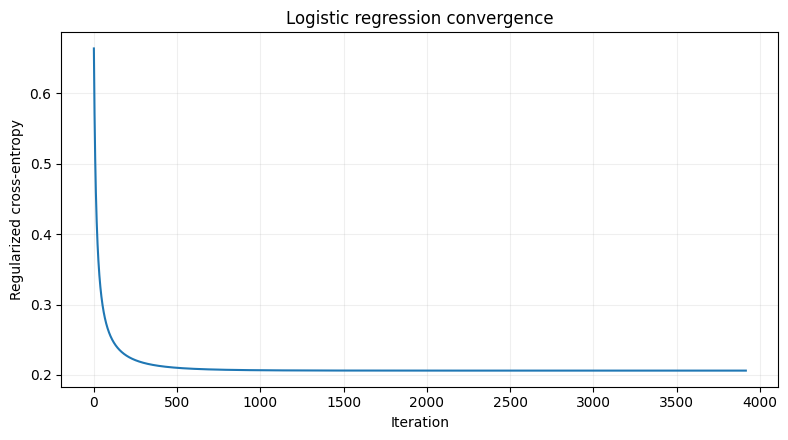

In [5]:
plt.figure(figsize=(8, 4.5))
plt.plot(numpy_model.loss_history_)
plt.xlabel("Iteration")
plt.ylabel("Regularized cross-entropy")
plt.title("Logistic regression convergence")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(ASSETS / "cross_entropy_loss.png", dpi=160)
plt.show()

## Compare with scikit-learn

We use a very large `C` to make regularization weak. Small numerical differences are expected because solvers and stopping rules differ.

In [6]:
sklearn_model = LogisticRegression(C=1e6, max_iter=5000, solver="lbfgs")
sklearn_model.fit(X_train, y_train)
p_sklearn = sklearn_model.predict_proba(X_test)[:, 1]

print("scikit-learn intercept:", np.round(sklearn_model.intercept_, 5))
print("scikit-learn coefficients:", np.round(sklearn_model.coef_[0], 5))
print("Probability correlation:", round(np.corrcoef(p_numpy, p_sklearn)[0, 1], 8))
print("Mean absolute probability difference:", round(np.mean(np.abs(p_numpy - p_sklearn)), 8))

scikit-learn intercept: [-0.15179]
scikit-learn coefficients: [3.49388 1.75863]
Probability correlation: 0.99999995
Mean absolute probability difference: 0.00011647


## Decision boundary

A probability threshold of 0.5 corresponds to a linear score of zero. The boundary is linear because no nonlinear features were added.

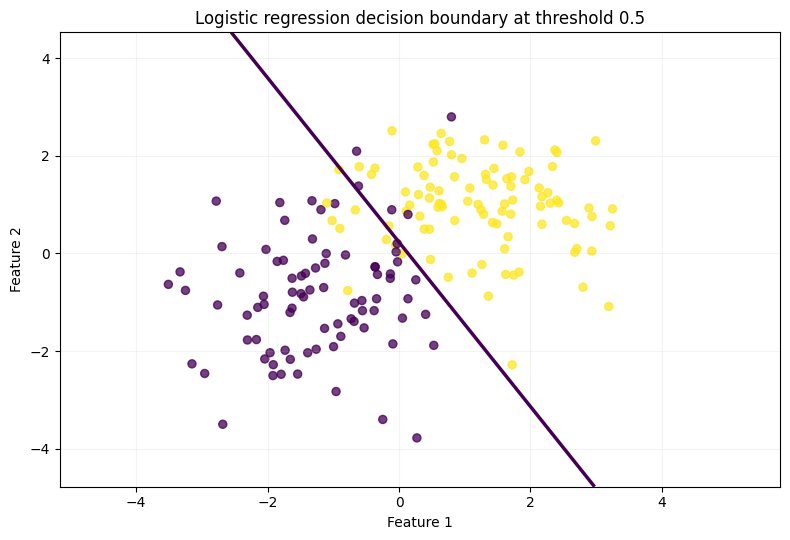

In [7]:
grid_x1, grid_x2 = np.meshgrid(
    np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 250),
    np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 250),
)
grid_raw = np.column_stack([grid_x1.ravel(), grid_x2.ravel()])
grid_scaled = scaler.transform(grid_raw)
grid_probability = numpy_model.predict_proba(grid_scaled)[:, 1].reshape(grid_x1.shape)

plt.figure(figsize=(8, 5.5))
plt.contour(grid_x1, grid_x2, grid_probability, levels=[0.5], linewidths=2.5)
plt.scatter(X_test_raw[:, 0], X_test_raw[:, 1], c=y_test, s=34, alpha=0.75)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Logistic regression decision boundary at threshold 0.5")
plt.grid(alpha=0.15)
plt.tight_layout()
plt.savefig(ASSETS / "logistic_decision_boundary.png", dpi=160)
plt.show()

## Numerical stability check

A stable sigmoid handles extreme scores without returning `NaN` or overflowing.

In [8]:
extreme = np.array([-1000.0, -100.0, 0.0, 100.0, 1000.0])
print(np.column_stack([extreme, stable_sigmoid(extreme)]))
print("Cross-entropy:", binary_cross_entropy(np.array([0, 1]), np.array([1e-12, 1 - 1e-12])))

[[-1.00000000e+03  0.00000000e+00]
 [-1.00000000e+02  3.72007598e-44]
 [ 0.00000000e+00  5.00000000e-01]
 [ 1.00000000e+02  1.00000000e+00]
 [ 1.00000000e+03  1.00000000e+00]]
Cross-entropy: 9.999778782803785e-13


## Interview reflection

Explain aloud:

1. Why cross-entropy is a better objective than accuracy.
2. Why a coefficient is linear in log-odds rather than probability.
3. Why matching regularization is necessary when comparing implementations.
4. Why the next chapter evaluates more than accuracy.